# Evaluate Ranking Loss for Ultra Low N Learning

In [1]:
%load_ext autoreload
%autoreload 2
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import seaborn as sns

# Configure logging
import logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(name)s - %(levelname)s - %(message)s')
logger = logging.getLogger()

from folde.data import get_available_proteingym_datasets, get_proteingym_dataset
from folde.campaign import simulate_campaign, simulate_campaigns
from folde.types import FolDEModelConfig, ModelEvaluation

In [2]:
available_datasets = get_available_proteingym_datasets('300m_extras', '600m')
assert not available_datasets.empty
available_datasets.head(10)

2025-05-01 22:08:31,848 - folde.data - INFO - Loaded metadata for 217 DMS datasets
2025-05-01 22:08:31,888 - folde.data - INFO - Found 9 datasets with embedding model '300m_extras' and naturalness model '600m'


,DMS_id,DMS_filename,UniProt_ID,taxon,source_organism,target_seq,seq_len,includes_multiple_mutants,DMS_total_number_mutants,DMS_number_single_mutants,...,raw_DMS_filename,raw_DMS_phenotype_name,raw_DMS_directionality,raw_DMS_mutant_column,weight_file_name,pdb_file,pdb_range,ProteinGym_version,raw_mut_offset,coarse_selection_type
15,ANCSZ_Hobbs_2022,ANCSZ_Hobbs_2022.csv,ANCSZ,Eukaryote,Reconstructed ancestor,MADSANHLPYFYGSITREEAEDYLKQGGMSDGLFLLRQSLNSLGGY...,627,False,4670,4670,...,ANCSZ_Hobbs_2022.csv,DMS_value,1,mutant,ANCSZ_theta_0.2.npy,ANCSZ.pdb,1-627,1.0,NaN,Activity
21,BLAT_ECOLX_Firnberg_2014,BLAT_ECOLX_Firnberg_2014.csv,BLAT_ECOLX,Prokaryote,Escherichia coli,MSIQHFRVALIPFFAAFCLPVFAHPETLVKVKDAEDQLGARVGYIE...,286,False,4783,4783,...,BLAT_ECOLX_Firnberg_2014.csv,linear,1,mutant,BLAT_ECOLX_theta_0.2.npy,BLAT_ECOLX.pdb,1-286,0.1,NaN,OrganismalFitness
36,CBS_HUMAN_Sun_2020,CBS_HUMAN_Sun_2020.csv,CBS_HUMAN,Human,Homo sapiens,MPSETPQAEVGPTGCPHRSGPHSAKGSLEKGSPEDKEAKEPLWIRP...,551,False,7217,7217,...,NaN,score,1,mutant,CBS_HUMAN_theta0.2_2023-10-12_b08.npy,CBS_HUMAN.pdb,1-551,1.0,NaN,OrganismalFitness
72,HEM3_HUMAN_Loggerenberg_2023,HEM3_HUMAN_Loggerenberg_2023.csv,HEM3_HUMAN,Human,Homo sapiens,MSGNGNAAATAEENSPKMRVIRVGTRKSQLARIQTDSVVATLKASY...,361,False,5689,5689,...,NaN,score,1,mutant,HEM3_HUMAN_theta0.2_2023-08-07_b02.npy,HEM3_HUMAN.pdb,1-361,1.0,NaN,Activity
76,HSP82_YEAST_Flynn_2019,HSP82_YEAST_Flynn_2019.csv,HSP82_YEAST,Eukaryote,Saccharomyces cerevisiae,MASETFEFQAEITQLMSLIINTVYSNKEIFLRELISNASDALDKIR...,709,False,13294,13294,...,HSP82_YEAST_Flynn_2019.csv,s (37°C),1,mutant,HSP82_YEAST_theta_0.2.npy,HSP82_YEAST.pdb,1-709,1.0,NaN,OrganismalFitness
78,HXK4_HUMAN_Gersing_2022_activity,HXK4_HUMAN_Gersing_2022_activity.csv,HXK4_HUMAN,Human,Homo sapiens,MLDDRARMEAAKKEKVEQILAEFQLQEEDLKKVMRRMQKEMDRGLR...,465,False,8570,8570,...,HXK4_HUMAN_Gersing_2022.csv,score,1,mutant,HXK4_HUMAN_theta_0.2.npy,HXK4_HUMAN.pdb,1-465,1.0,NaN,OrganismalFitness
114,OXDA_RHOTO_Vanella_2023_activity,OXDA_RHOTO_Vanella_2023_activity.csv,OXDA_RHOTO,Eukaryote,Rhodotorula gracilis,HSQKRVVVLGSGVIGLSSALILARKGYSVHILARDLPEDVSSQTFA...,364,False,6396,6396,...,Figure_2.xlsx,activity fitness,1,mutant,OXDA_RHOTO_theta0.2_2023-08-07_b02.npy,OXDA_RHOTO.pdb,1-364,1.0,NaN,Activity
133,PPM1D_HUMAN_Miller_2022,PPM1D_HUMAN_Miller_2022.csv,PPM1D_HUMAN,Human,Homo sapiens,MAGLYSLGVSVFSDQGGRKYMEDVTQIVVEPEPTAEEKPSPRRSLS...,605,False,7889,7889,...,PPM1D_HUMAN_Miller_2022_raw.xlsx,fitness,1,mutant,PPM1D_HUMAN_theta0.2_2023-10-12_b01.npy,PPM1D_HUMAN.pdb,1-605,1.0,NaN,OrganismalFitness
178,SHOC2_HUMAN_Kwon_2022,SHOC2_HUMAN_Kwon_2022.csv,SHOC2_HUMAN,Human,Homo sapiens,MSSSLGKEKDSKEKDPKVPSAKEREKEAKASGGFGKESKEKEPKTK...,582,False,10972,10972,...,2022.3.16.Extended Data Table 4.csv,LFC_scaled,1,variant.by.aa,SHOC2_HUMAN_theta0.2_2023-10-12_b04.npy,SHOC2_HUMAN.pdb,1-582,1.0,NaN,OrganismalFitness


In [12]:

config_list = [
    FolDEModelConfig(
        name='Random',
        naturalness_model_id="600m",
        embedding_model_id="300m_extras",
        zero_shot_model_name="RandomZeroShotModel",
        zero_shot_model_params={},
        few_shot_model_name="RandomFewShotModel",
        few_shot_model_params={}
    ),
    FolDEModelConfig(
        name="RandomForest",
        # Required parameters
        naturalness_model_id="600m",  # ESM-2 650M model
        embedding_model_id="300m_extras",  # Same model for embeddings
        zero_shot_model_name="RandomZeroShotModel",
        zero_shot_model_params={},
        # Few-shot model configuration (used after first round)
        few_shot_model_name="RandomForestFewShotModel",
        few_shot_model_params={
            "n_estimators": 100,
            "criterion": "friedman_mse",
            "max_depth": None,
            "min_samples_split": 2,
            "min_samples_leaf": 1,
            "min_weight_fraction_leaf": 0.0,
            "max_features": 1.0,
            "max_leaf_nodes": None,
            "min_impurity_decrease": 0.0,
            "bootstrap": True,
            "oob_score": False,
            "n_jobs": None,
            "verbose": 0,
            "warm_start": False,
            "ccp_alpha": 0.0,
            "max_samples": None,
        },
    ),
    FolDEModelConfig(
        name="MLP_MSE",
        # Required parameters
        naturalness_model_id="600m",  # ESM-2 650M model
        embedding_model_id="300m_extras",  # Same model for embeddings
        zero_shot_model_name="RandomZeroShotModel",
        zero_shot_model_params={},
        # Few-shot model configuration (used after first round)
        few_shot_model_name="TorchMLPFewShotModel",
        few_shot_model_params={
            'embedding_dim': 960,
            'hidden_dims': [100, 50],
            'dropout': 0.2,  # I don't know if this is important.
            'learning_rate': 1e-3,   # I MADE THIS HIGHER BECAUSE THE DEFAULT WASN'T LEARNING
            'weight_decay': 1e-5,
            'use_mse_loss': True,
        },
    ),
    FolDEModelConfig(
        name="MLP_MSE_ENSEMBLE",
        # Required parameters
        naturalness_model_id="600m",  # ESM-2 650M model
        embedding_model_id="300m_extras",  # Same model for embeddings
        zero_shot_model_name="RandomZeroShotModel",
        zero_shot_model_params={},
        # Few-shot model configuration (used after first round)
        few_shot_model_name="TorchMLPFewShotModel",
        few_shot_model_params={
            'embedding_dim': 960,
            'hidden_dims': [100, 50],
            'dropout': 0.2,  # I don't know if this is important.
            'learning_rate': 1e-3,   # I MADE THIS HIGHER BECAUSE THE DEFAULT WASN'T LEARNING
            'weight_decay': 1e-5,
            'use_mse_loss': True,
            'ensemble_size': 5,
        },
    ),
    FolDEModelConfig(
        name="MLP_Ranking",
        # Required parameters
        naturalness_model_id="600m",  # ESM-2 650M model
        embedding_model_id="300m_extras",  # Same model for embeddings
        zero_shot_model_name="RandomZeroShotModel",
        zero_shot_model_params={},
        # Few-shot model configuration (used after first round)
        few_shot_model_name="TorchMLPFewShotModel",
        few_shot_model_params={
            'embedding_dim': 960,
            'hidden_dims': [100, 50],
            'dropout': 0.2,  # I don't know if this is important.
            'learning_rate': 1e-3,   # I MADE THIS HIGHER BECAUSE THE DEFAULT WASN'T LEARNING
            'weight_decay': 1e-5,
        },
    ),
    FolDEModelConfig(
        name="MLP_Ranking_ENSEMBLE",
        # Required parameters
        naturalness_model_id="600m",  # ESM-2 650M model
        embedding_model_id="300m_extras",  # Same model for embeddings
        zero_shot_model_name="RandomZeroShotModel",
        zero_shot_model_params={},
        # Few-shot model configuration (used after first round)
        few_shot_model_name="TorchMLPFewShotModel",
        few_shot_model_params={
            'embedding_dim': 960,
            'hidden_dims': [100, 50],
            'dropout': 0.2,  # I don't know if this is important.
            'learning_rate': 1e-3,   # I MADE THIS HIGHER BECAUSE THE DEFAULT WASN'T LEARNING
            'weight_decay': 1e-5,
            'ensemble_size': 5,
        },
    ),
]

In [17]:
import tqdm
from folde.util import convert_compaign_result_collection_to_df

round_metrics_df = pd.DataFrame()

for round_size in tqdm.tqdm([256, 128, 64, 32, 16]):
    results = simulate_campaigns(
        name=f'round_size_{round_size}',
        dms_ids=available_datasets['DMS_id'].values,
        round_size=round_size,
        number_of_simulations=10,
        config_list=config_list,
        activity_column="DMS_score",
        max_rounds=2,
        random_seed=42,
    )
    single_mutant_df, single_round_metrics_df = convert_compaign_result_collection_to_df(results)
    single_round_metrics_df['round_size'] = round_size
    round_metrics_df = pd.concat([round_metrics_df, single_round_metrics_df])



  0%|          | 0/5 [00:00<?, ?it/s]2025-04-27 08:40:51,400 - folde.campaign - INFO - Running simulations for configuration 1/6
2025-04-27 08:40:51,402 - folde.campaign - INFO - Config: name='Random' naturalness_model_id='600m' embedding_model_id='300m_extras' embedding_column=None zero_shot_model_name='RandomZeroShotModel' zero_shot_model_params={} few_shot_model_name='RandomFewShotModel' few_shot_naturalness_column=None few_shot_model_params={}
2025-04-27 08:40:51,470 - folde.data - INFO - Loaded activity data for ANCSZ_Hobbs_2022 with 4670 rows
2025-04-27 08:40:59,528 - folde.data - INFO - Loaded embeddings for ANCSZ_Hobbs_2022 with 11914 rows
2025-04-27 08:40:59,699 - folde.data - INFO - Loaded naturalness scores for ANCSZ_Hobbs_2022 with 20691 rows
2025-04-27 08:41:14,013 - folde.campaign - INFO - Running simulation 1 (2335 / 4670 mutants in sim)
2025-04-27 08:41:14,618 - folde.campaign - INFO - Running simulation 2 (2335 / 4670 mutants in sim)
2025-04-27 08:41:15,086 - folde.cam

held_out_activity_spearman  \
round_size config_name                                        
16         MLP_MSE                                 0.200415   
           MLP_MSE_ENSEMBLE                        0.206080   
           MLP_Ranking                             0.193162   
           MLP_Ranking_ENSEMBLE                    0.194364   
           Random                                  0.015982   
           RandomForest                            0.155914   
32         MLP_MSE                                 0.194696   
           MLP_MSE_ENSEMBLE                        0.168519   
           MLP_Ranking                             0.165085   
           MLP_Ranking_ENSEMBLE                    0.164094   
           Random                                  0.015982   
           RandomForest                            0.147538   
64         MLP_MSE                                 0.170012   
           MLP_MSE_ENSEMBLE                        0.148469   
           MLP_Ranking                             0.160195   
           MLP_Ranking_ENSEMBLE                    0.150298   
           Random                                  0.015982   
           RandomForest                            0.143732   
128        MLP_MSE                                 0.169416   
           MLP_MSE_ENSEMBLE                        0.155954   
           MLP_Ranking                             0.171016   
           MLP_Ranking_ENSEMBLE                    0.159887   
           Random                                  0.015982   
           RandomForest                            0.136909   
256        MLP_MSE                                 0.170087   
           MLP_MSE_ENSEMBLE                        0.151986   
           MLP_Ranking                             0.174069   
           MLP_Ranking_ENSEMBLE                    0.163347   
           Random                                  0.015982   
           RandomForest                            0.133789   

                                 held_out_10pct_recall  held_out_1pct_recall  
round_size config_name                                                        
16         MLP_MSE                            0.044287              0.020402  
           MLP_MSE_ENSEMBLE                   0.047237              0.022461  
           MLP_Ranking                        0.043332              0.025671  
           MLP_Ranking_ENSEMBLE               0.042888              0.024728  
           Random                             0.015521              0.014160  
           RandomForest                       0.038406              0.018140  
32         MLP_MSE                            0.044396              0.022829  
           MLP_MSE_ENSEMBLE                   0.039759              0.028428  
           MLP_Ranking                        0.043209              0.035900  
           MLP_Ranking_ENSEMBLE               0.042074              0.039861  
           Random                             0.015521              0.014160  
           RandomForest                       0.038841              0.022931  
64         MLP_MSE                            0.045760              0.028741  
           MLP_MSE_ENSEMBLE                   0.045234              0.035490  
           MLP_Ranking                        0.047511              0.033309  
           MLP_Ranking_ENSEMBLE               0.043680              0.032896  
           Random                             0.015521              0.014160  
           RandomForest                       0.043595              0.032054  
128        MLP_MSE                            0.048424              0.041488  
           MLP_MSE_ENSEMBLE                   0.053691              0.051673  
           MLP_Ranking                        0.053810              0.043968  
           MLP_Ranking_ENSEMBLE               0.054114              0.047050  
           Random                             0.015521              0.014160  
           RandomForest                  

In [21]:
results.campaign_results[0].config_results[0].simulation_results[0].round_metrics

[RoundMetrics(round_num=1, model_spearman=0.01793144288970084, misc={'held_out_activity_spearman': -0.03128072781009003, 'held_out_1pct_recall': 0.0, 'held_out_1pct_auc': 0.3988533102553007, 'held_out_10pct_recall': 0.08974358974358974, 'held_out_10pct_auc': 0.48867450176350696}),
 RoundMetrics(round_num=2, model_spearman=-0.0026323814481688003, misc={'held_out_activity_spearman': -0.013260459925834373, 'held_out_1pct_recall': 0.0, 'held_out_1pct_auc': 0.5441908264820424, 'held_out_10pct_recall': 0.09401709401709402, 'held_out_10pct_auc': 0.5070519939629887})]

# Plot results

In [1]:
from folde.util import convert_compaign_result_collection_to_df
import json
from folde.types import ModelEvaluation

with open('notebooks/jacob/model_evals/250426_cs294.json', 'r') as f:
  iterative_results = ModelEvaluation(**json.load(f))
_, iterative_round_metrics_df = convert_compaign_result_collection_to_df(iterative_results)
iterative_round_metrics_df['training_points'] = (iterative_round_metrics_df['round_num'] - 1) * 16
iterative_round_metrics_df['training_type'] = 'iterative'
iterative_round_metrics_df['config_name'] = iterative_round_metrics_df['config_name'].replace({
    'Random': 'Random',
    'Random->RandomForestCtrl': 'RandomForest',
    'Random->MLP_MSE': 'MLP_MSE',
    'Random->MLP_Ranking': 'MLP_Ranking',
})

In [2]:
with open('notebooks/jacob/model_evals/250425_fix_recall_bug.json', 'r') as f:
  fix_results = ModelEvaluation(**json.load(f))
_, fix_metrics_df = convert_compaign_result_collection_to_df(fix_results)
fix_metrics_df['training_points'] = (fix_metrics_df['round_num'] - 1) * 16
fix_metrics_df = fix_metrics_df[fix_metrics_df.config_name.isin(['Naturalness->TorchMLPRankingLoss', 'Naturalness->TorchMLPRankingLossUCB', 'Naturalness->TorchMLPRankingLossUCB_PretrainProb'])]
fix_metrics_df['training_type'] = 'iterative'
fix_metrics_df['config_name'] = fix_metrics_df['config_name'].replace({
    'Naturalness->TorchMLPRankingLoss': 'Naturalness+MLP_Ranking',
    'Naturalness->TorchMLPRankingLossUCB': 'Naturalness+MLP_Ranking+UCB',
    'Naturalness->TorchMLPRankingLossUCB_PretrainProb': 'Naturalness+MLP_Ranking+UCB+Pretrain',
})

In [4]:
import pandas as pd
round_metrics_df = pd.read_csv('notebooks/jacob/cs294/250427_cs294.csv').melt(
    id_vars=['metric', 'round_size'],
    # value_vars=['Random', 'RandomForest', 'MLP_MSE', 'MLP_MSE_ENSEMBLE', 'MLP_Ranking', 'MLP_Ranking_ENSEMBLE'],
    var_name='model',
    value_name='value'
).pivot_table(
    index=['round_size', 'model'],
    columns='metric',
    values='value'
).reset_index()
round_metrics_df['config_name'] = round_metrics_df.model

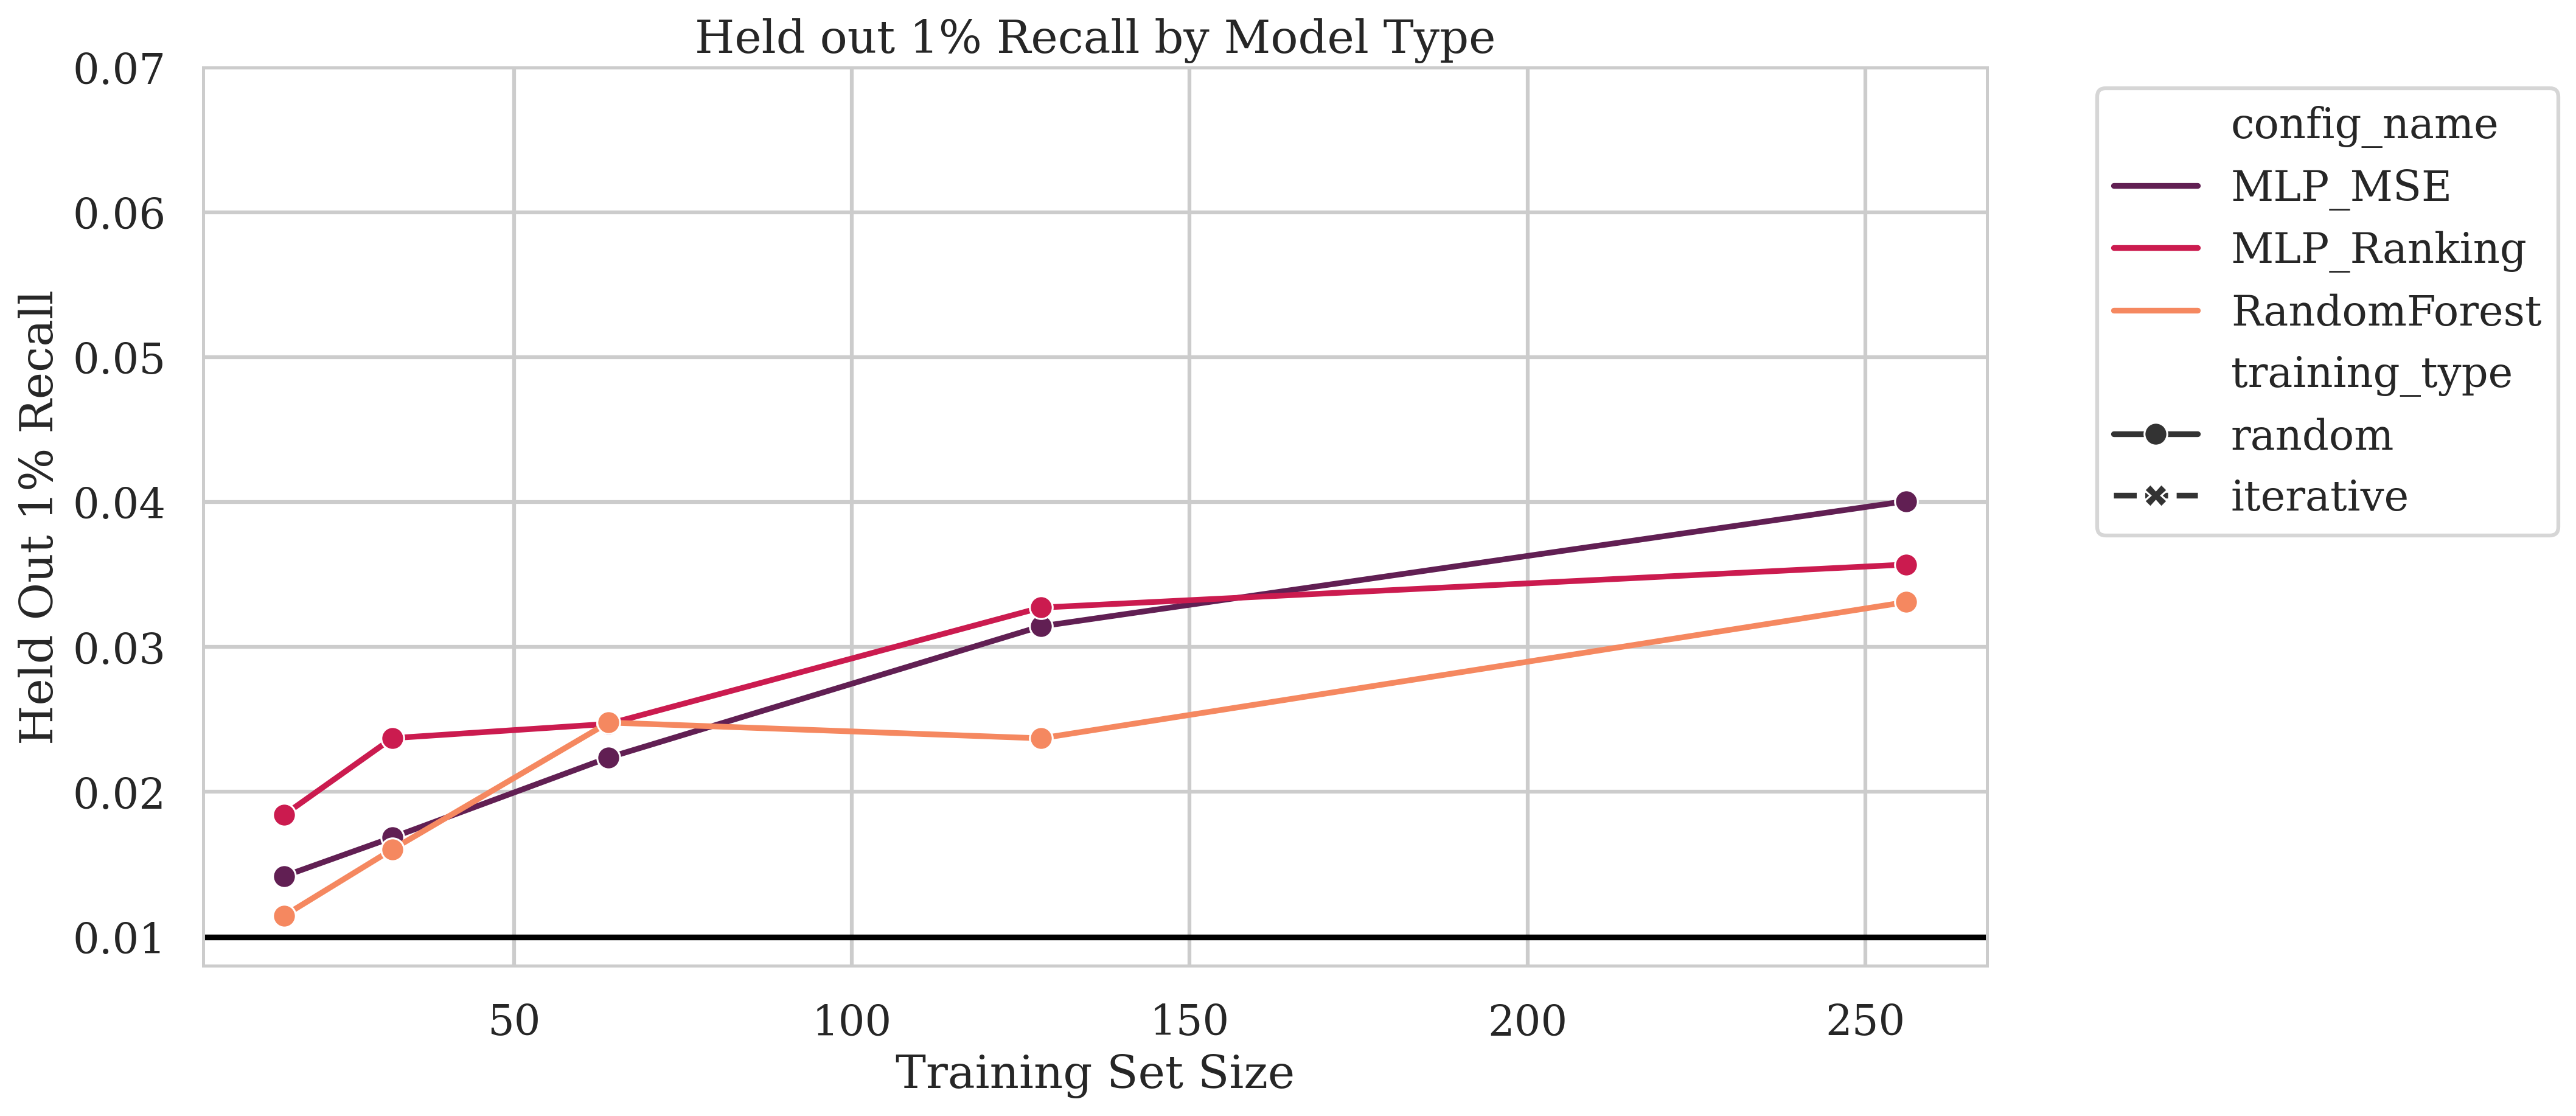

In [26]:
from matplotlib import pyplot as plt
import seaborn as sns

random_training_round_metrics_df = round_metrics_df.copy()
random_training_round_metrics_df['training_points'] = random_training_round_metrics_df.round_size
random_training_round_metrics_df['training_type'] = 'random'

combined_round_metrics_df = pd.concat([random_training_round_metrics_df, iterative_round_metrics_df, fix_metrics_df])
combined_round_metrics_df = combined_round_metrics_df[~combined_round_metrics_df.config_name.isin(['MLP_MSE_ENSEMBLE', 'MLP_Ranking_ENSEMBLE', 'Random'])]

combined_round_metrics_df = combined_round_metrics_df[
    combined_round_metrics_df['training_type'] == 'random'
]
combined_round_metrics_df = combined_round_metrics_df[
    combined_round_metrics_df.config_name.isin(['MLP_MSE', 'MLP_Ranking', 'RandomForest'])
]

fig = plt.figure(figsize=(14, 6), dpi=300, constrained_layout=True)
sns.set_style("whitegrid")  # Clean grid style
plt.style.use("seaborn-v0_8-paper")  # Scientific paper style
sns.set_context("talk")  # Larger text and elements
# Set font to serif for traditional scientific look
plt.rc('font', family='serif')
plt.rc('axes', linewidth=1.2)

sns.lineplot(
    # [combined_round_metrics_df['training_type'] == 'random']\
    data=combined_round_metrics_df\
    [combined_round_metrics_df.training_points != 0]\
    .groupby(['training_points', 'config_name', 'training_type'])\
    ['held_out_1pct_recall']\
    .mean()\
    .reset_index(),
    x='training_points',
    y='held_out_1pct_recall',
    hue='config_name',
    style='training_type',
    legend=True,
    # hue_order=['Random', 'RandomForest', 'MLP_MSE', 'MLP_Ranking'],
    style_order=['random', 'iterative'],
    markers=True,
    palette='rocket'
)

plt.axhline(y=0.01, color='black')

plt.title('Held out 1% Recall by Model Type')
plt.xlabel('Training Set Size')
plt.ylabel('Held Out 1% Recall')
# plt.ylim(0, 0.055)

# Add legend with a semi-transparent background
# plt.legend(framealpha=0.8, loc='lower right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(0.008, 0.07)

# Adjust layout to prevent label cutoff
# plt.tight_layout()

plt.savefig('notebooks/jacob/cs294/recall_by_model_type_full.png')

In [68]:
big_table = round_metrics_df\
  [round_metrics_df.round_num == 2]\
  .groupby(['round_size', 'config_name'])\
  [['held_out_activity_spearman', 'held_out_10pct_recall', 'held_out_1pct_recall']]\
  .mean()\
  .reset_index()\
  [['round_size', 'config_name', 'held_out_activity_spearman', 'held_out_10pct_recall', 'held_out_1pct_recall']]\
  .melt(id_vars=['round_size', 'config_name'], var_name='metric', value_name='metric_value')\
  .pivot(index=['metric','round_size'], columns=['config_name'], values='metric_value')\
  [['Random', 'RandomForest', 'MLP_MSE', 'MLP_MSE_ENSEMBLE', 'MLP_Ranking', 'MLP_Ranking_ENSEMBLE']]
big_table.to_csv('notebooks/jacob/250427_cs294.csv')

In [69]:
big_table

config_name                              Random  RandomForest   MLP_MSE  \
metric                     round_size                                     
held_out_10pct_recall      16          0.101472      0.143297  0.120637   
                           32          0.101472      0.151846  0.132864   
                           64          0.101472      0.158540  0.148229   
                           128         0.101472      0.168211  0.160178   
                           256         0.101472      0.181652  0.175747   
held_out_1pct_recall       16          0.006729      0.011456  0.014187   
                           32          0.006729      0.016032  0.016854   
                           64          0.006729      0.024790  0.022370   
                           128         0.006729      0.023700  0.031432   
                           256         0.006729      0.033102  0.040069   
held_out_activity_spearman 16         -0.000146      0.261917  0.205121   
                           32         -0.000146      0.328271  0.251941   
                           64         -0.000146      0.380860  0.303304   
                           128        -0.000146      0.423333  0.355082   
                           256        -0.000146      0.456764  0.391865   

config_name                            MLP_MSE_ENSEMBLE  MLP_Ranking  \
metric                     round_size                                  
held_out_10pct_recall      16                  0.127905     0.133323   
                           32                  0.143947     0.144288   
                           64                  0.158108     0.153988   
                           128                 0.170019     0.165111   
                           256                 0.184750     0.176103   
held_out_1pct_recall       16                  0.015707     0.018419   
                           32                  0.022834     0.023713   
                           64                  0.028596     0.024697   
                           128                 0.040090     0.032724   
                           256                 0.051460     0.035695   
held_out_activity_spearman 16                  0.215389     0.257133   
                           32                  0.315498     0.314708   
                           64                  0.374844     0.352590   
                           128                 0.408932     0.379980   
                           256                 0.448683     0.402057   

config_name                            MLP_Ranking_ENSEMBLE  
metric                     round_size                        
held_out_10pct_recall      16                      0.134366  
                           32                      0.144671  
                           64                      0.154488  
                           128                     0.169905  
                           256                     0.181918  
held_out_1pct_recall       16                      0.017076  
                           32                      0.024931  
                           64                      0.025010  
                           128                     0.037064  
                           256                     0.039021  
held_out_activity_spearman 16                      0.261897  
                           32                      0.325019  
                           64                      0.369081  
                           128                     0.410492  
                           256                     0.441130

In [ ]:
gb = round_metrics_df\
  [(round_metrics_df.round_num == 2) & (round_metrics_df.round_size == 16)]\
  .groupby(['config_name', 'dms_id'])\
  ['held_out_1pct_recall']
table = gb\
  .mean()\
  .reset_index()\
  .pivot(index='dms_id', columns='config_name', values='held_out_1pct_recall')\
  [['Random', 'RandomForest', 'MLP_MSE', 'MLP_Ranking', 'MLP_MSE_ENSEMBLE', 'MLP_Ranking_ENSEMBLE']]
table

config_name,Random,RandomForest,MLP_MSE,MLP_Ranking,MLP_MSE_ENSEMBLE,MLP_Ranking_ENSEMBLE
dms_id,,,,,,
ANCSZ_Hobbs_2022,0.000000,0.020833,0.008333,0.033333,0.020833,0.033333
BLAT_ECOLX_Firnberg_2014,0.012500,0.012500,0.020833,0.020833,0.020833,0.016667
CBS_HUMAN_Sun_2020,0.005405,0.013514,0.018919,0.018919,0.016216,0.016216
HEM3_HUMAN_Loggerenberg_2023,0.006897,0.006897,0.013793,0.017241,0.010345,0.010345
HSP82_YEAST_Flynn_2019,0.013433,0.011940,0.025373,0.023881,0.026866,0.026866
HXK4_HUMAN_Gersing_2022_activity,0.000000,0.013953,0.013953,0.016279,0.020930,0.016279
OXDA_RHOTO_Vanella_2023_activity,0.009375,0.009375,0.006250,0.009375,0.006250,0.006250
PPM1D_HUMAN_Miller_2022,0.007500,0.005000,0.007500,0.015000,0.010000,0.015000
SHOC2_HUMAN_Kwon_2022,0.005455,0.009091,0.012727,0.010909,0.009091,0.012727


In [66]:
def make_latex_table_with_bold_max(df, caption="Caption", label="tab:label"):
    from io import StringIO
    import pandas as pd
    
    # Format numbers and bold the max per row
    formatted_df = df.copy()
    
    def format_row(row):
        max_val = row.max()
        formatted = []
        for val in row:
            if pd.isna(val):
                formatted.append("")
            elif val == max_val:
                formatted.append(f"\\textbf{{{val:.3f}}}")
            else:
                formatted.append(f"{val:.3f}")
        return pd.Series(formatted, index=row.index)
    
    formatted_df = formatted_df.apply(format_row, axis=1)
    
    # Now build LaTeX
    buf = StringIO()
    columns = list(formatted_df.columns)
    ncols = len(columns)
    
    buf.write("\\begin{table}\n")
    buf.write("  \\centering\n")
    buf.write(f"  \\caption{{{caption}}}\n")
    buf.write(f"  \\label{{{label}}}\n")
    buf.write("  \\resizebox{\\linewidth}{!}{%\n")
    buf.write(f"  \\begin{{tabular}}{{l|{'c'*ncols}}}\n")
    buf.write("    \\toprule\n")
    sanitized_columns = [col.replace("_", "\\_") for col in columns]
    header = "DMS ID & " + " & ".join(f"\\textbf{{{col}}}" for col in sanitized_columns) + " \\\\\n"
    buf.write("    " + header)
    buf.write("    \\midrule\n")
    
    for idx, row in formatted_df.iterrows():
        sanitized_idx = idx.replace("_", "\\_")
        line = f"    \\texttt{{{sanitized_idx}}} & " + " & ".join(row) + " \\\\\n"
        buf.write(line)
    
    buf.write("    \\bottomrule\n")
    buf.write("  \\end{tabular}%\n")
    buf.write("}\n")
    buf.write("\\end{table}\n")
    
    return buf.getvalue()
print(make_latex_table_with_bold_max(table))

\begin{table}
  \centering
  \caption{Caption}
  \label{tab:label}
  \resizebox{\linewidth}{!}{%
  \begin{tabular}{l|cccccc}
    \toprule
    DMS ID & \textbf{Random} & \textbf{RandomForest} & \textbf{MLP\_MSE} & \textbf{MLP\_Ranking} & \textbf{MLP\_MSE\_ENSEMBLE} & \textbf{MLP\_Ranking\_ENSEMBLE} \\
    \midrule
    \texttt{ANCSZ\_Hobbs\_2022} & 0.000 & 0.021 & 0.008 & \textbf{0.033} & 0.021 & \textbf{0.033} \\
    \texttt{BLAT\_ECOLX\_Firnberg\_2014} & 0.013 & 0.013 & \textbf{0.021} & \textbf{0.021} & \textbf{0.021} & 0.017 \\
    \texttt{CBS\_HUMAN\_Sun\_2020} & 0.005 & 0.014 & \textbf{0.019} & \textbf{0.019} & 0.016 & 0.016 \\
    \texttt{HEM3\_HUMAN\_Loggerenberg\_2023} & 0.007 & 0.007 & 0.014 & \textbf{0.017} & 0.010 & 0.010 \\
    \texttt{HSP82\_YEAST\_Flynn\_2019} & 0.013 & 0.012 & 0.025 & 0.024 & \textbf{0.027} & \textbf{0.027} \\
    \texttt{HXK4\_HUMAN\_Gersing\_2022\_activity} & 0.000 & 0.014 & 0.014 & 0.016 & \textbf{0.021} & 0.016 \\
    \texttt{OXDA\_RHOTO\_Vanella\_2023